# Posterior Inference using Swyft (TMNRE)

Simulation-Based Inference (SBI) with **Truncated Marginal Neural Ratio Estimation (TMNRE** using [`swyft`](https://swyft.readthedocs.io/en/stable/))is a hyper-efficient approach to parameter inference that learns likelihood-to-evidence ratios for arbitrary marginal posteriors. Unlike Neural Posterior Estimation (NPE) as used in the `sbi` tutorial, TMNRE estimates **marginal** posteriors directly (no need to fit the full joint), requiring fewer simulations in principle. 

In [ ]:
## Additional dependencies (beyond a standard X-PSI install):
! pip install swyft pytorch-lightning

## Initialization

In [2]:
## IMPORTANT: Import torch before xpsi
import torch
import torch.nn as nn

import swyft

import numpy as np
import math
from matplotlib import pyplot as plt
from matplotlib import rcParams

rc = {"font.family": "serif", "mathtext.fontset": "stix"}
plt.rcParams.update(rc)
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
plt.rcParams.update({"font.size": 18, "legend.fontsize": 15})

import xpsi
import xpsi.SBI_wrapper as SBI_wrapper
import xpsi.utilities.Example_CNNs as CNNs

import sys
## Add your path to the example modules
sys.path.append("../../examples/examples_fast/Modules/")
import main

# Check that cuda is available
DEVICE = "gpu" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

KeyboardInterrupt: 

## Setting up X-PSI interface for swyft

First we follow procedures for synthetic data generation that will be used by SBI to generate training data. We use the `SBI_wrapper` module consisting of multiple classes and functions, including the usual data synthesis process but with some extended functionalities. Unlike the `x_p_sbi.ipynb` tutorial, we do **not** call `prepare_for_sbi`; instead we wrap the simulator in swyft's `Simulator` base class.

In [ ]:
_data = SBI_wrapper.SynthesiseData(main.Instrument.channels,
                                   main.data.phases,
                                   0,
                                   len(main.Instrument.channels) - 1)

Setting channels for event data...
Channels set.


In [ ]:
main.CustomSignal.synthesise = SBI_wrapper.synthesise
signal = main.CustomSignal(data=_data,
                           instrument=main.Instrument,
                           background=None,
                           interstellar=None,
                           prefix="instr",
                           cache=True)

Creating parameter:
    > Named "phase_shift" with fixed value 0.000e+00.
    > The phase shift for the signal, a periodic parameter [cycles].
No data... can synthesise data but cannot evaluate a likelihood function.


In the code block above, the background has been set to `None`.
In its current form, it's recommended to either fix the background or use a parameterized functional background model since the `default_background_marginalisation` is only utilized during the likelihood computation process that SBI skips. 

In principle, one may leave the background free and then allow the neural network to simply learn what the background is for any given dataset. However, performance in such a scenario has not been tested, and one may expect that to introduce too much degeneracy in the parameter space for SBI to work meaningfully.

In the code block below, we are using a `Custom_SBI_Likelihood` that inherits fromt the `xpsi.Likelihood` class and modifies that `_driver` and `synthesise` methods to return `model_flux` that is the synthesised signal, which then constitutes the training dataset.

In [ ]:
likelihood = SBI_wrapper.Custom_SBI_Likelihood(star=main.star,
                                               signals=signal,
                                               prior=main.prior,
                                               num_energies=64,
                                               threads=1)
print(likelihood)

Free parameters
---------------
mass: Gravitational mass [solar masses].
radius: Coordinate equatorial radius [km].
distance: Earth distance [kpc].
cos_inclination: Cosine of Earth inclination to rotation axis.
p__phase_shift: The phase of the hot region, a periodic parameter [cycles].
p__super_colatitude: The colatitude of the centre of the superseding region [radians].
p__super_radius: The angular radius of the (circular) superseding region [radians].
p__super_temperature: log10(superseding region effective temperature [K]).



In [ ]:
# Instrument kwargs used to call synthesise()
INSTR_KWARGS = dict(exposure_time = 1.0E+06,    # alternatively input 
                                                # expected_source_counts
                    nchannels = len(main.Instrument.channels),
                    nphases = len(main.data.phases))

PARAM_NAMES = [p.name for p in main.prior.parameters]
BOUNDS      = np.array([param.bounds for param in main.likelihood.params], dtype=np.float32)
N_PARAMS    = len(PARAM_NAMES)
N_CHANNELS  = INSTR_KWARGS["nchannels"]
N_PHASES    = INSTR_KWARGS["nphases"] - 1

## Define the Swyft Simulator

In `swyft`, a simulator is expressed as a **graphical model** via `swyft.Simulator`.
Each named node in the graph corresponds to a random variable:

- **`z`** — the free parameters, drawn from X-PSI's priors
- **`x`** — the simulated pulse-profile, produced by calling X-PSI's `synthesise`

The `build` method is called **once** at instantiation to construct the computational graph; all subsequent calls to `sim.sample(N)` reuse it.

> N.B. The X-PSI prior is not a simple uniform box — it may include correlations or derived parameters.

In [ ]:
class XPSISimulator(swyft.Simulator):
    """
    Swyft simulator that wraps the X-PSI pulse-profile generator.
    Uses the X-PSI prior directly for sampling (via prior.draw()).

    Graph nodes
    -----------
    z : np.ndarray, shape (N_PARAMS,)
        Free parameters drawn from the X-PSI prior via prior.draw().
    x_2d : np.ndarray, shape (1, N_CHANNELS, N_PHASES)
        2-D pulse profile for CNN-based networks.
    x : np.ndarray, shape (N_CHANNELS * N_PHASES,)
        Flattened pulse profile for MLP-based networks.
    """

    def __init__(self, prior, likelihood, instr_kwargs):
        super().__init__()
        self.transform_samples = swyft.to_numpy32
        self._prior        = prior       # xpsi.Prior instance
        self._likelihood   = likelihood
        self._instr_kwargs = instr_kwargs

    # Prior sampler 
    def _sample_prior(self):
        samples, _ = self._prior.draw(1)
        return samples[0].astype(np.float32)

    # Pulse-profile simulator — calls X-PSI synthesise
    def _simulate(self, z):
        self._instr_kwargs['seed'] = np.random.randint(0, int(1e15))
        profile = self._likelihood.synthesise(z.tolist(), force=True, instr=self._instr_kwargs)
        return np.asarray(profile, dtype=np.float32)  # shape (N_CHANNELS, N_PHASES)

    # Swyft graph definition
    def build(self, graph):
        z    = graph.node("z", self._sample_prior)
        x_2d = graph.node("x_2d", lambda z: self._simulate(z)[np.newaxis, :, :], z)
        graph.node("x", lambda x_2d: x_2d.flatten(), x_2d)

sim = XPSISimulator(prior=main.prior,
                    likelihood=likelihood,
                    instr_kwargs=INSTR_KWARGS)

# Sanity check
test_sample = sim.sample(N=1)
print("z shape:",    test_sample["z"].shape)
print("x shape:",    test_sample["x"].shape)
print("x_2d shape:", test_sample["x_2d"].shape)

  0%|          | 0/1 [00:00<?, ?it/s]

Drawing samples from the joint prior...
Samples drawn.
z shape: (1, 8)
x shape: (1, 9312)
x_2d shape: (1, 1, 291, 32)


## Generate Training Samples

We generate samples in memory using `sim.sample(N)`. For large training sets, consider using `swyft.ZarrStore` (on-disk storage) to allow parallel simulation and re-use across runs

In [ ]:
N_TRAIN = 1000   # Reduce number for quick testing.

print(f"Simulating {N_TRAIN} training samples...")
samples = sim.sample(N=N_TRAIN)
print("Done.")
print("  z shape:", samples["z"].shape)
print("  x shape:", samples["x"].shape)

Simulating 10000 training samples...


  0%|          | 0/10000 [00:00<?, ?it/s]

Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing sa

## Build the Inference Network

The swyft network is a `swyft.SwyftModule` whose `forward(A, B)` method returns one or more `LogRatioSamples` objects.

We provide two network architectures in this notebook:

### MLP network (simple baseline)
Uses a linear embedding layer to compress the flattened profile before ratio estimation. Fast to train, ignores 2-D spatial structure.

### CNN network (recommended)
Processes the 2-D pulse profile with convolutional layers before estimating both per-parameter 1-D marginals and selected 2-D joint marginals. Phase-energy-resolved pulse profiles are equivalent to 2D (grayscale) images. Therefore, Convolutional Neural Networks (CNNs) can be utilized, in principle, to better capture neighbouring information between adjacent sets of pixels. `xpsi.utilities.Example_CNNs` provides a set of CNN architectures, including pre-trained architectures from PyTorch `ResNet` and `ResNeXt`.
Below we use the relatively simple CNN architecture `C2P1_FC1`.

In [ ]:
class XPSINetworkMLP(swyft.SwyftModule):
    """
    Simple MLP embedding + per-parameter 1-D marginal ratio estimators.
    Uses the flattened pulse profile 'x'.
    """

    def __init__(
        self,
        n_obs: int,       # N_CHANNELS * N_PHASES
        n_params: int,    # N_PARAMS
        embed_dim: int = 64,
        param_names: str = "z",
    ):
        super().__init__()
        self.embedding = nn.Sequential(
            nn.Linear(n_obs, 256),
            nn.ReLU(),
            nn.Linear(256, embed_dim),
            nn.ReLU(),
        )
        self.logratios_1d = swyft.LogRatioEstimator_1dim(
            num_features=embed_dim,
            num_params=n_params,
            varnames=param_names,
        )

    def forward(self, A, B):
        f = self.embedding(torch.as_tensor(A["x"]))
        return self.logratios_1d(f, torch.as_tensor(B["z"]))


class XPSINetworkCNN(swyft.SwyftModule):
    """
    CNN embedding using C2P1_FC1 from xpsi.utilities.Example_CNNs.
    Uses 'x_2d' (shape: 1 x N_CHANNELS x N_PHASES).
    """

    def __init__(
        self,
        n_channels: int,
        n_phases: int,
        n_params: int,
        embed_dim: int = 10,   # matches fc_out_features in C2P1_FC1 (default 10)
        param_names: str = "z",
        joint_marginals=None,
    ):
        super().__init__()

        self.cnn = CNNs.C2P1_FC1(nchannels=n_channels,
                                 nphases=n_phases,
                                 fc_out_features=embed_dim)

        # Per-parameter 1-D marginals
        self.logratios_1d = swyft.LogRatioEstimator_1dim(num_features=embed_dim,
                                                         num_params=n_params,
                                                         varnames=param_names)

        # Optional 2-D joint marginals
        self.logratios_2d = None
        if joint_marginals is not None:
            self.logratios_2d = swyft.LogRatioEstimator_Ndim(num_features=embed_dim,
                                                             marginals=joint_marginals,
                                                             varnames=param_names)

    def _embed(self, A):
        # C2P1_FC1.forward expects a flat or (B, N_CHANNELS*N_PHASES) tensor
        # and reshapes internally via x.view(-1, 1, nchannels, nphases)
        x = torch.as_tensor(A["x"]).float()   # use flat 'x', C2P1_FC1 handles reshaping
        return self.cnn(x)

    def forward(self, A, B):
        f = self._embed(A)
        z = torch.as_tensor(B["z"])
        out = self.logratios_1d(f, z)
        if self.logratios_2d is not None:
            out = (out, self.logratios_2d(f, z))
        return out

## Prepare DataModule and Instantiate the Network

In [ ]:
# swyft.SwyftDataModule splits the Samples into train/val loaders.
# The keyword argument changed between swyft versions:
#   v0.4.2 (stable release): val_fraction=float  (train/val only)
#   v0.4.3+ / dev branch:    fractions=[f1,f2,f3] (train/val/test)
# We detect which API is present at runtime so the notebook works with either.
import inspect as _inspect
_dm_sig = _inspect.signature(swyft.SwyftDataModule.__init__).parameters
if 'fractions' in _dm_sig:
    dm = swyft.SwyftDataModule(
        samples,
        fractions=[0.8, 0.1, 0.1],  # train / val / test  (v0.4.3+)
        batch_size=64,
        num_workers=0,
    )
else:
    dm = swyft.SwyftDataModule(
        samples,
        val_fraction=0.2,           # 20% val, 80% train  (v0.4.2)
        batch_size=64,
        num_workers=0,
    )

# # Select network architecture — swap to XPSINetworkMLP for the simpler version

import itertools
JOINT_MARGINALS = tuple(itertools.combinations(range(N_PARAMS), 2))
print(f"Number of 2-D pairs: {len(JOINT_MARGINALS)}")  # 28 for 8 parameters

network = XPSINetworkCNN(n_channels=N_CHANNELS,
                         n_phases=N_PHASES,
                         n_params=N_PARAMS,
                         embed_dim=64,
                         param_names="z",
                         joint_marginals=JOINT_MARGINALS)

/Users/dc1408/opt/anaconda3/envs/xpsbi/lib/python3.10/site-packages/torch/nn/modules/lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Number of 2-D pairs: 28


## Train

In [ ]:
trainer = swyft.SwyftTrainer(accelerator=DEVICE,
                             max_epochs=50,
                             precision=32)

trainer.fit(network, dm)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: ModelCheckpoint
/Users/dc1408/opt/anaconda3/envs/xpsbi/lib/python3.10/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:411: UserWarning: A layer with UninitializedParameter was found. Thus, the total number of parameters detected may be inaccurate.
  warning_cache.warn(

  | Name         | Type                   | Params
--------------------------------------------------------
0 | cnn          | C2P1_FC1               | 0     
1 | logratios_1d | LogRatioEstimator_1dim | 171 K 
2 | logratios_2d | LogRatioEstimator_Ndim | 602 K 
--------------------------------------------------------
773 K     Trainable params
0         Non-trainable params
773 K     Total params
3.095     Total estimated model 

Sanity Checking: 0it [00:00, ?it/s]

/Users/dc1408/opt/anaconda3/envs/xpsbi/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, val_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 16 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/Users/dc1408/opt/anaconda3/envs/xpsbi/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 16 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Reloading best model: /Users/dc1408/PhD_research/xpsi/docs/source/lightning_logs/version_11/checkpoints/epoch=7-step=1000.ckpt


Hooray! 🎉
Network trained! 🏃‍♂️💪

## 8. Inference on a Test Observation

We synthesise a "ground-truth" observation at known parameters, then run swyft inference to recover those parameters.

In [ ]:
# True parameter values used to generate the test observation
p_true = [
    1.4,                         # mass  [solar masses]
    12.0,                        # radius [km]
    1.0,                         # distance [kpc]
    math.cos(np.radians(60)),    # cos(inclination)
    0.5,                         # phase shift [cycles]
    np.radians(70),              # super colatitude [rad]
    0.75,                        # super radius [rad]
    6.7,                         # log10(T_eff) [K]
]

# Synthesise the observation using X-PSI directly
profile_true = likelihood.synthesise(p_true, force=True, instr=INSTR_KWARGS)
profile_true = np.asarray(profile_true, dtype=np.float32)

# Package as a swyft observation (single-sample dict)
obs = swyft.Sample({
    "x":    profile_true.flatten(),
    "x_2d": profile_true[np.newaxis, :, :],  # shape (1, N_CHANNELS, N_PHASES)
})

print("Test observation prepared.")
print("  x shape:",    obs["x"].shape)
print("  x_2d shape:", obs["x_2d"].shape)

Test observation prepared.
  x shape: (9312,)
  x_2d shape: (1, 291, 32)


In [ ]:
# Draw prior samples for posterior evaluation
# swyft evaluates the network on these to weight them into posterior samples
N_PRIOR = 10000
prior_samples = sim.sample(N=N_PRIOR, targets=["z"])  # only need z, not x

# Run inference
predictions = trainer.infer(network, obs, prior_samples)

print("Inference complete.")
print("predictions type:", type(predictions))

  0%|          | 0/10000 [00:00<?, ?it/s]

Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing sa

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint


Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples drawn.
Drawing samples from the joint prior...
Samples dr

Predicting: 125it [00:00, ?it/s]

/Users/dc1408/opt/anaconda3/envs/xpsbi/lib/python3.10/site-packages/pytorch_lightning/loops/epoch/prediction_epoch_loop.py:173: UserWarning: Lightning couldn't infer the indices fetched for your dataloader.
  warning_cache.warn("Lightning couldn't infer the indices fetched for your dataloader.")


Inference complete.
predictions type: <class 'list'>


## Plotting

### 1-D Marginal Posteriors

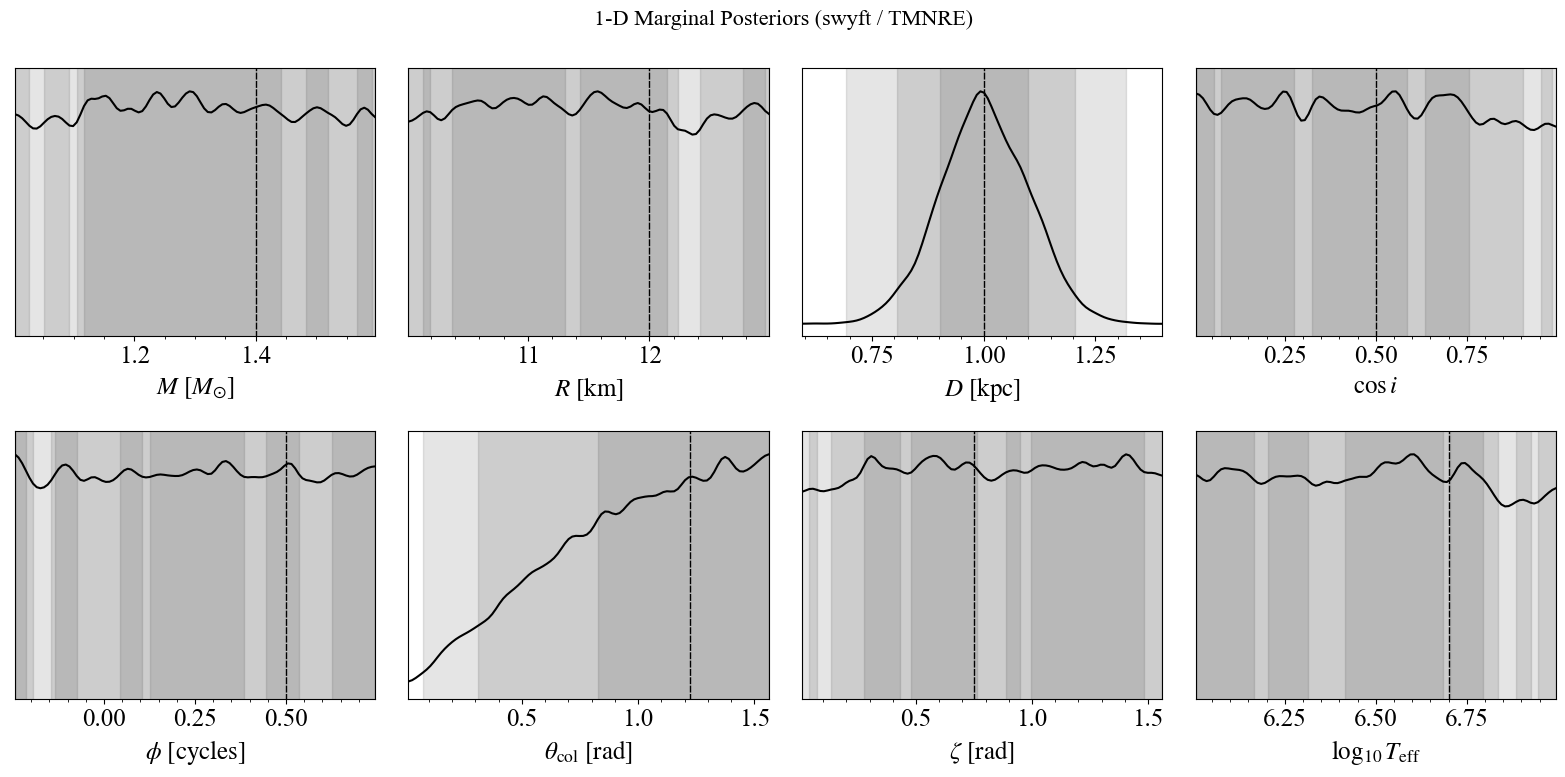

In [ ]:
from swyft.plot.plot import plot_posterior, plot_corner

PARAM_LABELS = [
    r"$M\ [M_{\odot}]$",
    r"$R\ [\mathrm{km}]$",
    r"$D\ [\mathrm{kpc}]$",
    r"$\cos i$",
    r"$\phi\ [\mathrm{cycles}]$",
    r"$\theta_{\mathrm{col}}\ [\mathrm{rad}]$",
    r"$\zeta\ [\mathrm{rad}]$",
    r"$\log_{10} T_{\mathrm{eff}}$",
]

pred_1d = predictions[0] if isinstance(predictions, tuple) else predictions

parnames = [f"z[{i}]" for i in range(N_PARAMS)]
truth_dict = {pn: val for pn, val in zip(parnames, p_true)}  # dict keyed by parname

plot_posterior(
    pred_1d,
    parnames=parnames,
    labels=PARAM_LABELS,
    truth=truth_dict,
    smooth=2.0,
    ncol=4,
    figsize=(16, 8),
)
plt.suptitle("1-D Marginal Posteriors (swyft / TMNRE)", fontsize=16)
plt.tight_layout()
plt.show()

### Corner Plot (1-D + 2-D marginals)

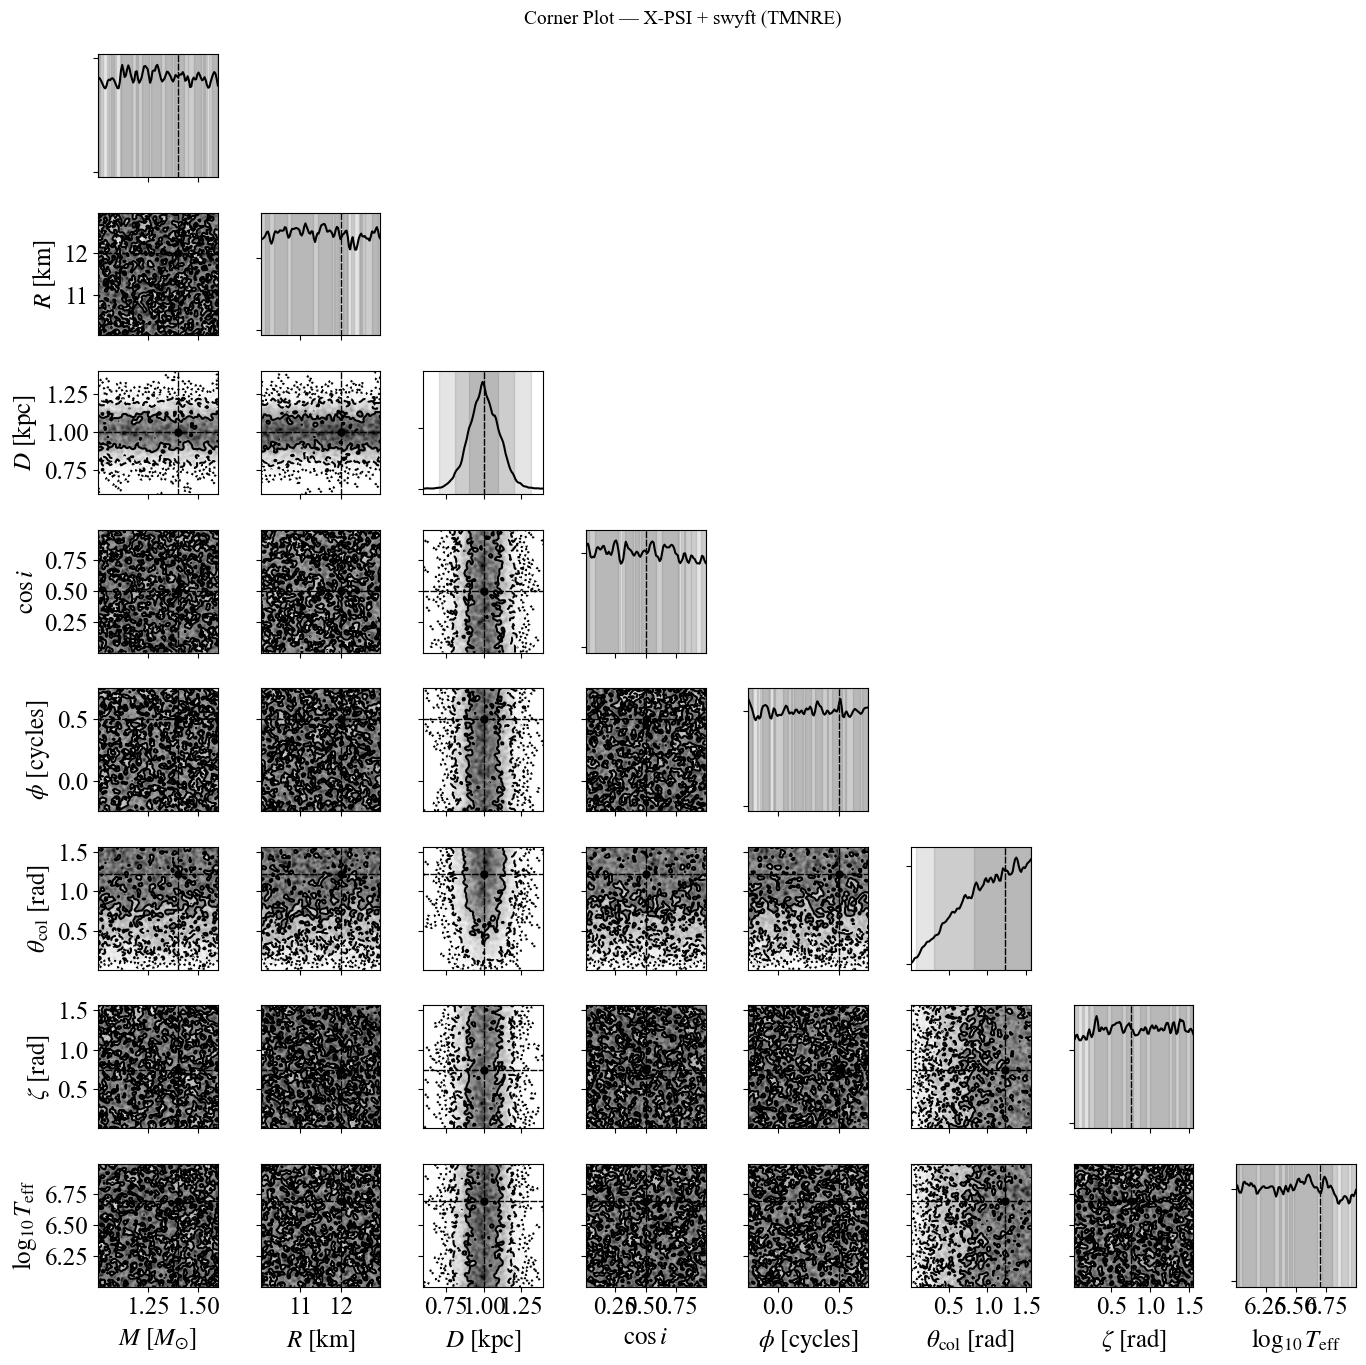

In [ ]:
plot_corner(
    predictions,          # full list: [LogRatioSamples_1d, LogRatioSamples_2d]
    parnames=parnames,
    labels=PARAM_LABELS,
    truth=truth_dict,
    smooth=1.0,
    figsize=(14, 14),
)
plt.suptitle("Corner Plot — X-PSI + swyft (TMNRE)", fontsize=14)
plt.tight_layout()
plt.show()

---

## Future suggestions (untested): On-Disk Storage with ZarrStore

For large training sets (≥ 10 000 simulations) or multi-node HPC runs, `swyft.ZarrStore` stores simulations on disk as a Zarr archive. Simulations can be appended in parallel batches and reused across training runs without re-simulating.

```python
import swyft

sim = XPSISimulator(likelihood=likelihood, bounds=BOUNDS, instr_kwargs=INSTR_KWARGS)
shapes, dtypes = sim.get_shapes_and_dtypes()

# Initialise a Zarr archive for 10 000 samples (chunk_size controls I/O granularity)
store = swyft.ZarrStore("./xpsi_swyft_store.zarr")
store.init(N=10_000, chunk_size=128, shapes=shapes, dtypes=dtypes)

# Simulate in batches (can be re-run to fill remaining slots)
store.simulate(sim, batch_size=100)

# Use the store directly as a data module
dm = swyft.SwyftDataModule(store, val_fraction=0.2, batch_size=64)  # or fractions=[0.8,0.1,0.1] on v0.4.3+
trainer.fit(network, dm)
```

## Future suggestions (untested): Targeted Inference via Prior Truncation

One of swyft's key advantages **iterative prior truncation**: after an initial round of inference, you can restrict the prior to the high-probability region and re-simulate there, achieving much better posterior resolution with fewer total simulations.

```python
import swyft

# After round 1 inference, obtain a truncated prior from the network predictions
# using swyft.Bound:
bound = swyft.Bound.from_ratio(
    predictions=pred_1d,
    parnames=[f"z[{i}]" for i in range(N_PARAMS)],
    th=-8.0,   # log-ratio threshold: keep samples where log r > th
)

# Draw samples from the truncated prior (much more efficient)
truncated_samples = sim.sample(
    N=5_000,
    conditions=bound  # only simulate where bound is active
)

# Retrain on the truncated samples and iterate
dm_truncated = swyft.SwyftDataModule(truncated_samples, val_fraction=0.2, batch_size=64)  # or fractions=[0.8,0.1,0.1] on v0.4.3+
trainer.fit(network, dm_truncated)
```